# (16) added sigma neurons

**Motivation**: host = ```mach```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.fighelper import *
from vae.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.chosen import *
from figures.analysis import *
from figures.imgs import plot_weights

device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## vH16

Intermediate beta: $(T, \beta) = (32, 16.0)$

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('vH16', model_type, 'jacob|lin')

cfg_vae['track_stats'] = True

seq_len = 32
cfg_vae['seq_len'] = seq_len
cfg_vae['portion_loc'] = 0.5
cfg_vae['n_latents'] = 1024

cfg_vae['clamp_sig'] = 4
cfg_vae['clamp_du'] = 5
cfg_vae['clamp_u'] = 5

cfg_tr['kl_anneal_portion'] = 0.3
cfg_tr['kl_beta'] = 4/8 * seq_len
cfg_tr['lr'] = 2e-3

In [4]:
vae = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = TrainerVAE(vae, ConfigTrainVAE(**cfg_tr), device=device)
print_num_params(vae.layer)

print(f"{vae.cfg.name()}\n{tr.cfg.name()}_({vae.timestamp})\n")
tr.n_iters

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  264.2 K   |
|     ———      |    ———     |
|     phi      |  131.1 K   |
|     psi      |  131.1 K   |
+--------------+------------+

poisson_vH16_t-32_z-[1024]_<jacob|lin>
b200-ep300-lr(0.002)_beta(16:0x0.3)_temp(0.05:lin-0.5)_gr(200)_(2024_10_17,09:53)

154500

In [ ]:
tr.train()

epoch # 63, avg loss: 201.572644:  21%|▊   | 63/300 [1:03:30<4:14:05, 64.33s/it]

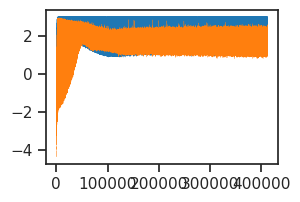

In [6]:
du_max = np.array(vae.stats['du_max'])
u_max = np.array(vae.stats['u_max'])

plt.plot(du_max, lw=0.2)
plt.plot(u_max, lw=0.2)

### Load

In [6]:
tr, meta = load_model(
    'poisson_vH16_t-8_z-[512]_<jacob|lin>',
    'b200-ep300-lr(0.002)_beta(8:0x0.1)_temp(0.05:lin-0.5)_gr(200)_(2024_10_16,17:46)',
    device=device,
)
meta['checkpoint']

300

In [6]:
tr.model.layer

PoissonLayer(dim=1024, input_dim=256, temp=0.55)

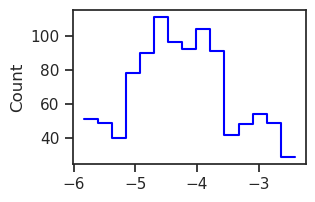

In [7]:
log_rate = tonp(tr.model.layer.log_rate.squeeze())
histplot(log_rate, color='b');

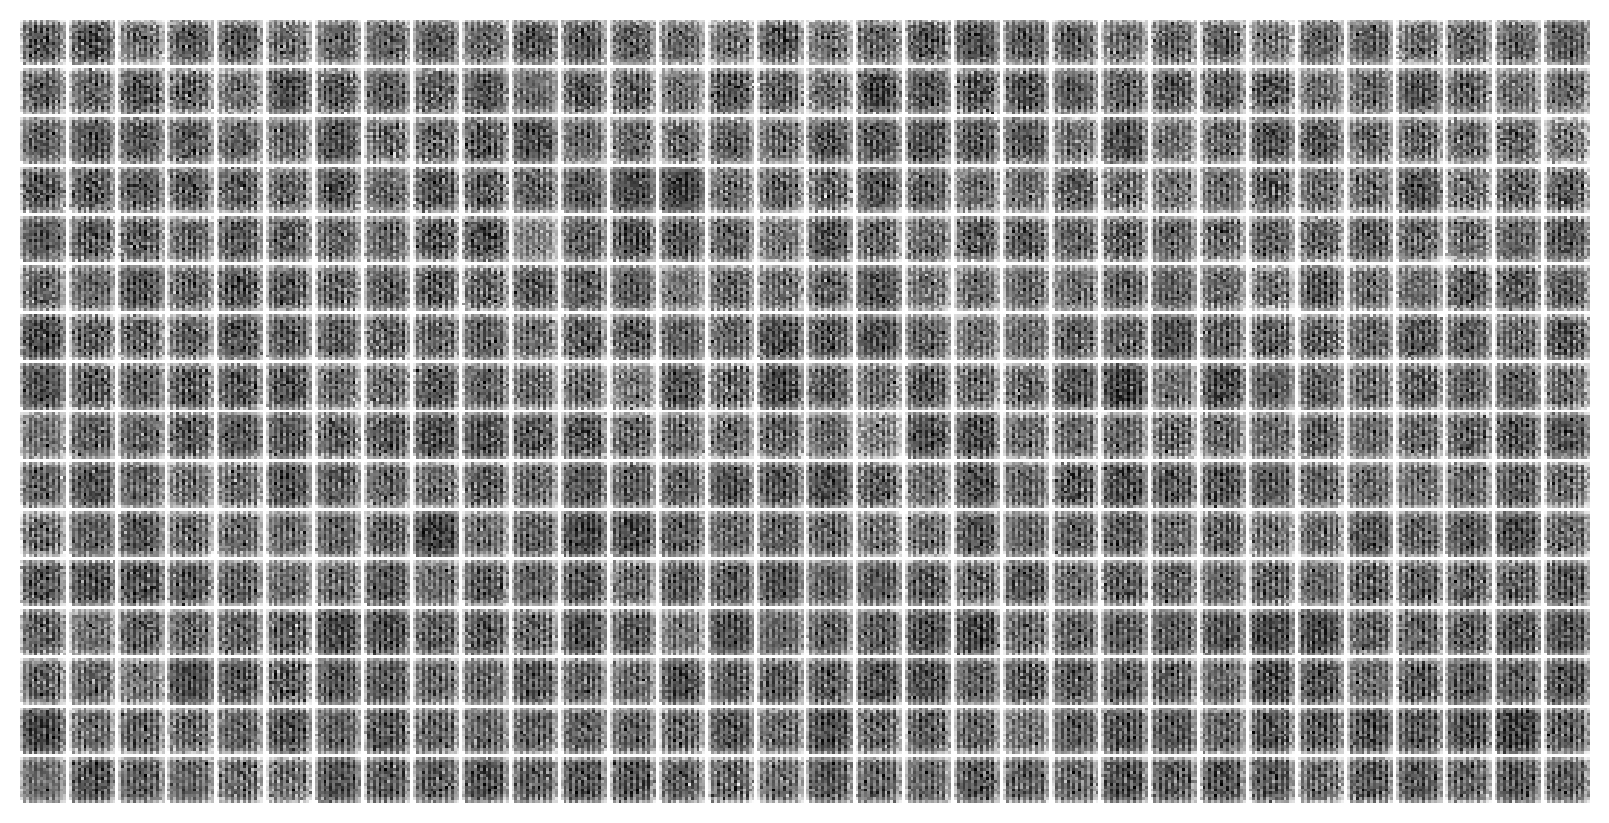

In [9]:
_ = tr.model.show(order=np.argsort(log_rate[:512]))

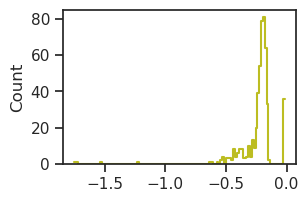

In [11]:
bias = tonp(tr.model.layer.bias.squeeze())
histplot(bias, color='C8');

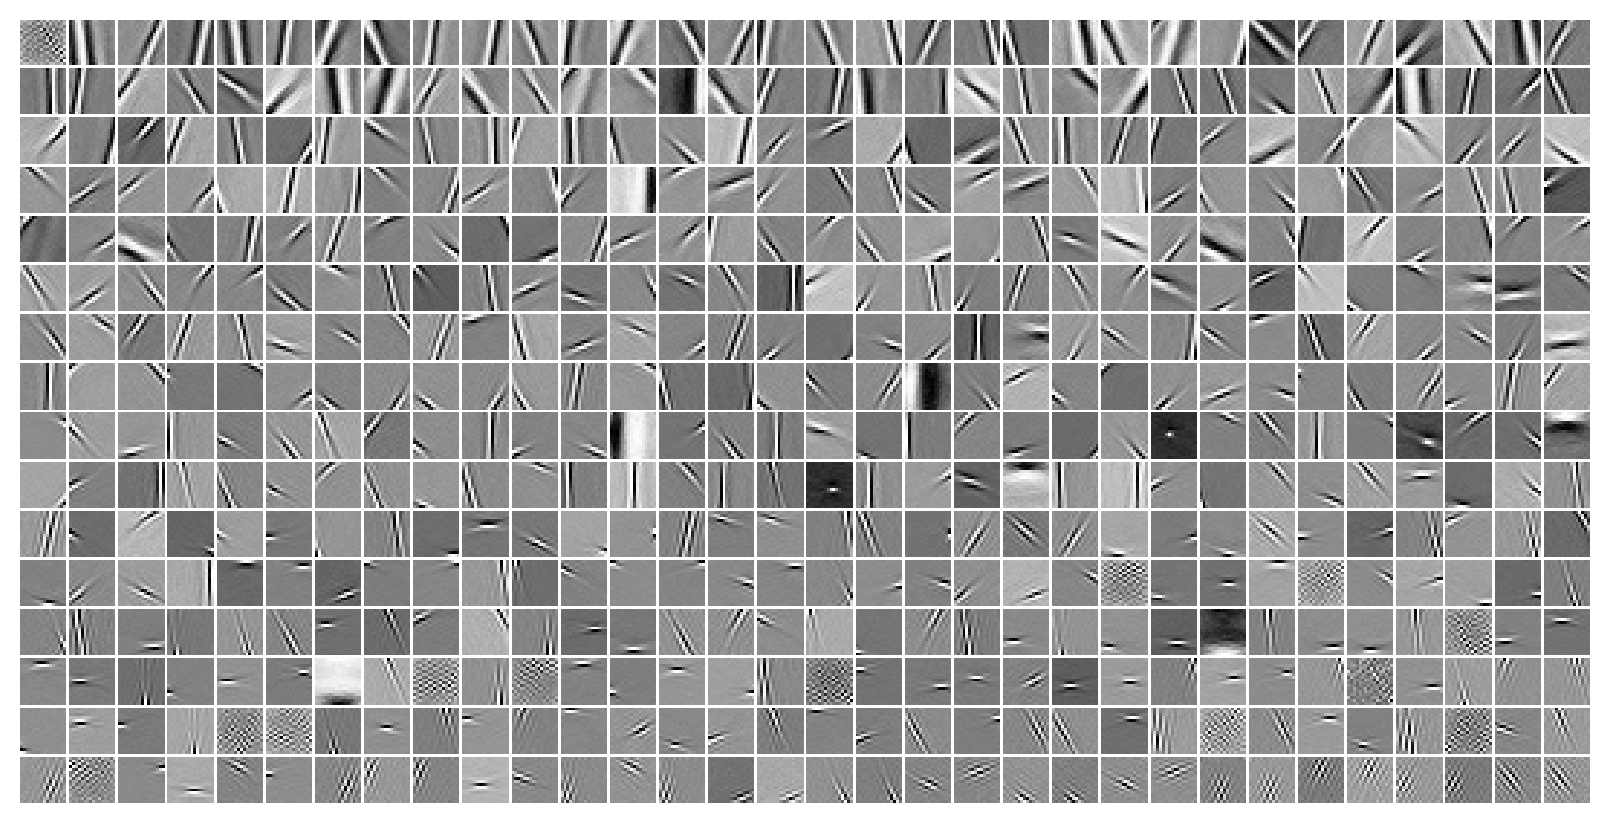

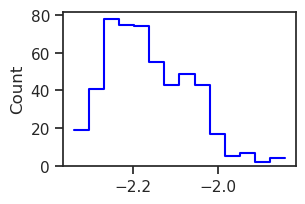

In [7]:
w = tr.model.layer.get_weight()
norms = tonp(torch.linalg.vector_norm(w, dim=1))

_ = tr.model.show(order=np.argsort(norms))

histplot(np.log(norms), label='log norm', color='b');

100%|███████████████████████████████████| 5/5 [00:40<00:00,  8.04s/it]


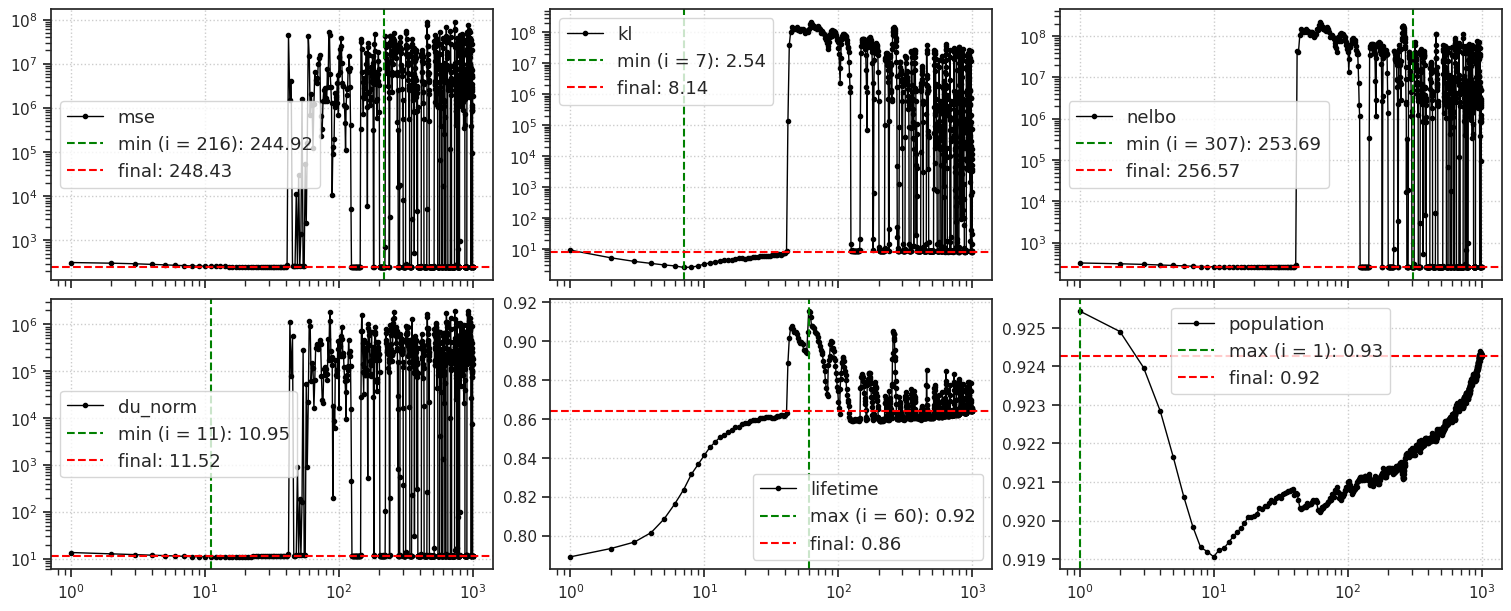

CPU times: user 43.6 s, sys: 1.55 s, total: 45.1 s
Wall time: 45.1 s


In [14]:
%%time

kws = dict(
    seq_total=1000,
    seq_batch_sz=1000,
    n_data_batches=5,
)
results = tr.analysis(**kws)

_ = plot_convergence(results, color='k')

In [8]:
x = next(iter(tr.dl_vld))[0]
x.shape

torch.Size([200, 1, 16, 16])

In [9]:
output = tr.model.xtract_ftr(
    x=x,
    seq=range(1000),
    return_extras=True,
).stack()

In [10]:
list(output)

['loss_kl', 'loss_recon', 'dist', 'ff', 'recon', 'state', 'samples']

In [11]:
output['ff'].shape

torch.Size([200, 1000, 512])

In [12]:
x2p = tonp(output['ff'].exp().mean(0))

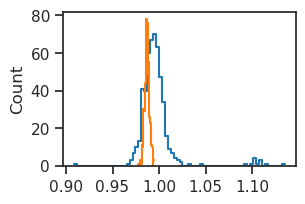

In [13]:
histplot(x2p[0])
histplot(x2p[-1]);

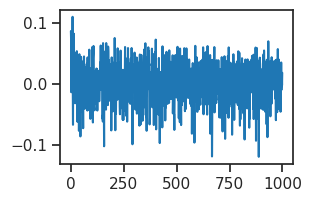

In [16]:
plot(output['ff'][123, :, 48]);

In [20]:
print(tr.model.layer.dec)

None